### Demo: Bilingual Course Description Similarity Detection

This notebook demonstrates the practical application of the evaluation pipeline developed in this thesis. 

LaBSE is loaded with the optimal threshold of 0.87 identified on the ICT dataset and applied to new course description pairs that 
were not part of any evaluation. 

The demo illustrates how the pipeline would function in a real curriculum management context, taking raw Finnish and English 
course description text as input and returning a similarity verdict with a confidence score.

### Setup: Loading LaBSE

In [1]:
import numpy as np
import torch
import warnings
from transformers import logging as hf_logging
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Color theme
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))

THRESHOLD = 0.87

print(f"LaBSE loaded on: {device}")
print(f"Similarity threshold: {THRESHOLD}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

LaBSE loaded on: cuda
Similarity threshold: 0.87


### Prediction Function

The prediction function takes a Finnish and English course description as raw text, encodes both using LaBSE, computes their cosine similarity, and returns a structured verdict. 

No preprocessing beyond what LaBSE handles internally is required, consistent with the finding that raw text produces the best results.

In [2]:
def predict_similarity(fi_text, en_text, threshold=THRESHOLD):
    # Encode both texts
    embeddings = model.encode([fi_text, en_text], 
                               convert_to_numpy=True,
                               show_progress_bar=False)
    
    # L2 normalize
    fi_emb = embeddings[0] / np.linalg.norm(embeddings[0])
    en_emb = embeddings[1] / np.linalg.norm(embeddings[1])
    
    # Cosine similarity
    similarity = float(np.dot(fi_emb, en_emb))
    
    # Verdict
    equivalent = similarity >= threshold
    
    return {
        'similarity_score': round(similarity, 4),
        'threshold': threshold,
        'verdict': 'EQUIVALENT' if equivalent else 'NOT EQUIVALENT',
        'confidence': 'High' if abs(similarity - threshold) > 0.05 else 'Low'
    }

def print_result(fi_text, en_text, result, pair_name):
    print(f"{'='*70}")
    print(f"Pair: {pair_name}")
    print(f"{'='*70}")
    print(f"Finnish: {fi_text[:200]}")
    print(f"English: {en_text[:200]}")
    print(f"{'-'*70}")
    print(f"Similarity Score: {result['similarity_score']}")
    print(f"Threshold:        {result['threshold']}")
    print(f"Verdict:          {result['verdict']}")
    print(f"Confidence:       {result['confidence']}")
    print(f"{'='*70}\n")

print("Prediction function ready.")

Prediction function ready.


### Proof of Concept: Cross-Lingual Course Retrieval

This cell demonstrates the core logic of the AI Curriculum Tool. A curriculum designer provides a course description in either Finnish or English. 

The system searches all existing courses in the database across both language versions simultaneously and returns any course that exceeds the similarity threshold. Because LaBSE maps Finnish and English into a shared semantic space, the language of the input does not affect retrieval quality. 

This directly addresses the practical motivation of the thesis: detecting duplicate or overlapping courses in a bilingual curriculum database without requiring manual comparison.

In [3]:
import pandas as pd

# Load the full course database
base = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final"
df = pd.read_csv(f"{base}/data/processed/dataset_preprocessed.csv")

# Build the course database: unique courses with both language versions
# Use only unique Finnish and English outcomes
fi_courses = df[['course_id', 'title_fi', 'title_en', 'outcomes_fi']].drop_duplicates(
    subset='course_id').reset_index(drop=True)
en_courses = df[['course_id', 'title_fi', 'title_en', 'outcomes_en']].drop_duplicates(
    subset='course_id').reset_index(drop=True)

# Pre-compute embeddings for all Finnish and English courses
print("Pre-computing course database embeddings...")

fi_texts = fi_courses['outcomes_fi'].tolist()
en_texts = en_courses['outcomes_en'].tolist()

fi_db_embs = model.encode(fi_texts, batch_size=32,
                           show_progress_bar=False, convert_to_numpy=True)
en_db_embs = model.encode(en_texts, batch_size=32,
                           show_progress_bar=False, convert_to_numpy=True)

# L2 normalize
fi_db_embs = fi_db_embs / np.linalg.norm(fi_db_embs, axis=1, keepdims=True)
en_db_embs = en_db_embs / np.linalg.norm(en_db_embs, axis=1, keepdims=True)

print(f"Database ready: {len(fi_courses)} courses indexed in Finnish and English")

Pre-computing course database embeddings...
Database ready: 154 courses indexed in Finnish and English


### Retrieval Function

The retrieval function accepts any text input regardless of language, encodes it with LaBSE, and searches the entire course database simultaneously in both Finnish and English. 

Results above the similarity threshold are returned ranked by score, giving the curriculum designer an immediate view of potential duplicates or overlapping courses.

In [4]:
def find_similar_courses(query_text, threshold=THRESHOLD, top_k=5):
    # Encode query
    query_emb = model.encode([query_text], convert_to_numpy=True,
                              show_progress_bar=False)[0]
    query_emb = query_emb / np.linalg.norm(query_emb)
    
    # Search Finnish database
    fi_scores = np.dot(fi_db_embs, query_emb)
    # Search English database
    en_scores = np.dot(en_db_embs, query_emb)
    
    results = []
    
    # Collect Finnish matches
    for idx, score in enumerate(fi_scores):
        if score >= threshold:
            results.append({
                'course_id': fi_courses.iloc[idx]['course_id'],
                'title_fi': fi_courses.iloc[idx]['title_fi'],
                'title_en': fi_courses.iloc[idx]['title_en'],
                'matched_language': 'Finnish',
                'similarity_score': round(float(score), 4),
                'matched_text': fi_courses.iloc[idx]['outcomes_fi'][:200]
            })
    
    # Collect English matches
    for idx, score in enumerate(en_scores):
        if score >= threshold:
            results.append({
                'course_id': en_courses.iloc[idx]['course_id'],
                'title_fi': en_courses.iloc[idx]['title_fi'],
                'title_en': en_courses.iloc[idx]['title_en'],
                'matched_language': 'English',
                'similarity_score': round(float(score), 4),
                'matched_text': en_courses.iloc[idx]['outcomes_en'][:200]
            })
    
    # Sort by score and remove duplicate course IDs
    results = sorted(results, key=lambda x: x['similarity_score'], reverse=True)
    seen_ids = set()
    unique_results = []
    for r in results:
        if r['course_id'] not in seen_ids:
            unique_results.append(r)
            seen_ids.add(r['course_id'])
    
    return unique_results[:top_k]

def print_retrieval_results(query_text, results):
    print(f"{'='*70}")
    print(f"Query: {query_text[:200]}")
    print(f"{'='*70}")
    if not results:
        print("No similar courses found above threshold.")
    else:
        print(f"Found {len(results)} similar course(s):\n")
        for i, r in enumerate(results, 1):
            print(f"Match {i}:")
            print(f"  Course ID:        {r['course_id']}")
            print(f"  Finnish Title:    {r['title_fi']}")
            print(f"  English Title:    {r['title_en']}")
            print(f"  Matched Language: {r['matched_language']}")
            print(f"  Similarity Score: {r['similarity_score']}")
            print(f"  Matched Text:     {r['matched_text']}")
            print()
    print(f"{'='*70}\n")

print("Retrieval function ready.")

Retrieval function ready.


### Demo Queries

Three queries demonstrate the retrieval system across different scenarios. The first query is in Finnish and searches for an existing equivalent course. 

The second query is in English and searches for the same course, demonstrating language-agnostic retrieval. 

The third query describes a completely new course that does not exist in the database, demonstrating that the system correctly returns no matches when there is no overlap.

In [5]:
# Query 1: Finnish input - existing course
query_fi = """
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien 
merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. 
Opiskelija tuntee ISO/IEC 27000 -standardisarjan sisällön ja osaa hyödyntää sitä 
kyberturvallisuuden hallinnassa.
"""

# Query 2: English input - same course content as query 1
query_en = """
The student understands the importance and principles of cyber security and 
information security management systems in organizations and society. The student 
knows the ISO/IEC 27000 series of standards and can apply them in cyber security 
management planning and implementation.
"""

# Query 3: English input - completely new course not in database
query_new = """
The student understands the principles of quantum computing and can apply quantum 
algorithms to solve computational problems. The student is familiar with quantum 
error correction methods and understands the current limitations of quantum hardware.
"""

print("QUERY 1: Finnish input (existing course)")
results_1 = find_similar_courses(query_fi)
print_retrieval_results(query_fi, results_1)

print("QUERY 2: English input (same course content as Query 1)")
results_2 = find_similar_courses(query_en)
print_retrieval_results(query_en, results_2)

print("QUERY 3: English input (new course not in database)")
results_3 = find_similar_courses(query_new)
print_retrieval_results(query_new, results_3)

QUERY 1: Finnish input (existing course)
Query: 
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien 
merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. 
Opiskelija tuntee ISO/IEC 27000 -sta
Found 1 similar course(s):

Match 1:
  Course ID:        TT00CE07
  Finnish Title:    Kyberturvallisuuden hallinta
  English Title:    Cyber Security management
  Matched Language: Finnish
  Similarity Score: 0.8851
  Matched Text:     Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa


QUERY 2: English input (same course content as Query 1)
Query: 
The student understands the importance and principles of cyber security and 
information security management systems in organizations and society. The student 
knows the ISO/IEC 27000 series of stand
Found 1 similar course(s):

Match 1:
  Course ID

In [6]:
# Query 4: Borderline case - partially overlapping course
query_borderline = """
The student understands network security fundamentals and can identify common 
security vulnerabilities in software systems. The student knows the basic principles 
of encryption and can apply security testing methods to evaluate system vulnerabilities.
"""

print("QUERY 4: Borderline case (partial overlap with cybersecurity courses)")
results_4 = find_similar_courses(query_borderline, threshold=0.80)
print_retrieval_results(query_borderline, results_4)

QUERY 4: Borderline case (partial overlap with cybersecurity courses)
Query: 
The student understands network security fundamentals and can identify common 
security vulnerabilities in software systems. The student knows the basic principles 
of encryption and can apply securi
Found 1 similar course(s):

Match 1:
  Course ID:        TT00CE17
  Finnish Title:    Web-sovellusten turvallisuuden testaus
  English Title:    Web Application Security Testing
  Matched Language: Finnish
  Similarity Score: 0.8126
  Matched Text:     Opiskelija oppii ymmärtämään yleisimmät websovellusten turvallisuuteen liittyvät juurisyyt, sekä oppii käytämään työkaluja ja menetelmiä yleisten verkkosovellusten havaitsemiseen ja hyödyntämiseen, se




### Visualising Retrieval Confidence Across All Demo Queries

The chart below shows the best similarity score returned for each query alongside the equivalence threshold and the overlap warning zone. 

This visualisation represents how the tool would present results to a curriculum designer, giving them both a clear verdict and a graded confidence score to support their decision.

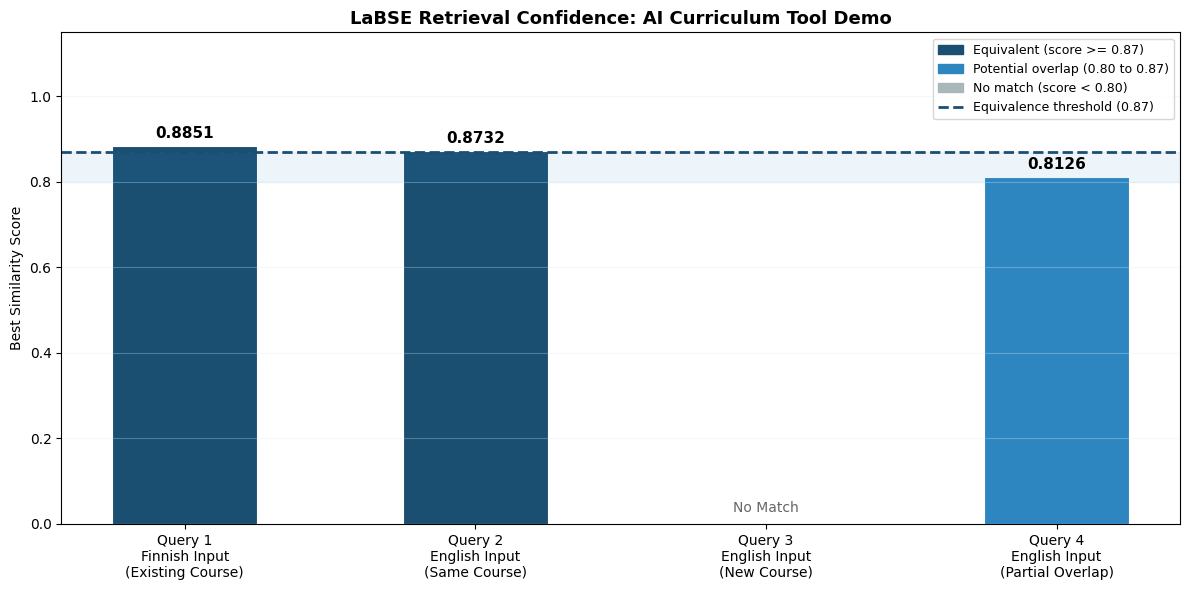

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\demo_retrieval.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

base = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final"
figures_dir = os.path.join(base, "figures", "main")
os.makedirs(figures_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

queries = [
    'Query 1\nFinnish Input\n(Existing Course)',
    'Query 2\nEnglish Input\n(Same Course)',
    'Query 3\nEnglish Input\n(New Course)',
    'Query 4\nEnglish Input\n(Partial Overlap)'
]

best_scores = [
    results_1[0]['similarity_score'] if results_1 else 0,
    results_2[0]['similarity_score'] if results_2 else 0,
    0,
    results_4[0]['similarity_score'] if results_4 else 0
]

bar_colors = []
for score in best_scores:
    if score >= 0.87:
        bar_colors.append(PRIMARY)
    elif score >= 0.80:
        bar_colors.append(SECONDARY)
    else:
        bar_colors.append(NEGATIVE)

bars = ax.bar(queries, best_scores, color=bar_colors,
              edgecolor='white', linewidth=0.8, width=0.5)

ax.axhline(y=0.87, color=PRIMARY, linestyle='--', linewidth=2)
ax.axhspan(0.80, 0.87, alpha=0.08, color=SECONDARY)

for bar, score in zip(bars, best_scores):
    if score > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                0.02, 'No Match', ha='center', va='bottom',
                fontsize=10, color='#666666')

ax.legend(handles=[
    mpatches.Patch(color=PRIMARY, label='Equivalent (score >= 0.87)'),
    mpatches.Patch(color=SECONDARY, label='Potential overlap (0.80 to 0.87)'),
    mpatches.Patch(color=NEGATIVE, label='No match (score < 0.80)'),
    plt.Line2D([0], [0], color=PRIMARY, linestyle='--',
               linewidth=2, label='Equivalence threshold (0.87)')
], fontsize=9)

ax.set_title('LaBSE Retrieval Confidence: AI Curriculum Tool Demo',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Best Similarity Score')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'demo_retrieval.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

### Notebook Summary

This notebook demonstrated the practical application of the thesis pipeline as a proof of concept for the AI Curriculum Tool. 

LaBSE was deployed as a cross-lingual retrieval system that accepts course description input in any language and searches the full course database simultaneously in Finnish and English. 

The demo confirmed four distinct operational scenarios: a Finnish query correctly retrieving an existing Finnish course, an English query retrieving the same course by matching against its Finnish database entry, a genuinely new course producing no false matches, and a partially overlapping course being flagged in the overlap warning zone between 0.80 and 0.87. 

These results demonstrate that the pipeline is ready for integration into the AI Curriculum Tool and can support curriculum designers in detecting duplicate or overlapping courses without requiring manual bilingual comparison.